In [54]:
import pandas as pd
import numpy as np
import seaborn as sns

In [19]:
test = pd.read_csv('../data/raw/cs-test.csv', index_col=0)
train = pd.read_csv('../data/raw/cs-training.csv', index_col=0)
sample = pd.read_csv('../data/raw/sampleEntry.csv', index_col=0)

In [20]:
test.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [21]:
train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [22]:
sample.head()

,Probability
Id,
1,0.080807
2,0.040719
3,0.011968
4,0.067640
5,0.108264


# Working with train
SeriousDlqin2yrs - target variable


In [31]:
train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [30]:
print(f'shape {train.shape}')
print(f'dublicates {train.duplicated().sum()}')

shape (150000, 11)
dublicates 609


In [24]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [34]:
train['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64

In [39]:
train.isna().sum()


SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [40]:
train.isna().mean().sort_values(ascending=False)


MonthlyIncome                           0.198207
NumberOfDependents                      0.026160
SeriousDlqin2yrs                        0.000000
RevolvingUtilizationOfUnsecuredLines    0.000000
age                                     0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
DebtRatio                               0.000000
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
dtype: float64

In [41]:
train.groupby(train['MonthlyIncome'].isna())['SeriousDlqin2yrs'].mean()

MonthlyIncome
False    0.069486
True     0.056137
Name: SeriousDlqin2yrs, dtype: float64

Calculate the percent of people without income in each target status

In [45]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


array([[<Axes: title={'center': 'SeriousDlqin2yrs'}>,
        <Axes: title={'center': 'RevolvingUtilizationOfUnsecuredLines'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'NumberOfTime30-59DaysPastDueNotWorse'}>,
        <Axes: title={'center': 'DebtRatio'}>,
        <Axes: title={'center': 'MonthlyIncome'}>],
       [<Axes: title={'center': 'NumberOfOpenCreditLinesAndLoans'}>,
        <Axes: title={'center': 'NumberOfTimes90DaysLate'}>,
        <Axes: title={'center': 'NumberRealEstateLoansOrLines'}>],
       [<Axes: title={'center': 'NumberOfTime60-89DaysPastDueNotWorse'}>,
        <Axes: title={'center': 'NumberOfDependents'}>, <Axes: >]],
      dtype=object)

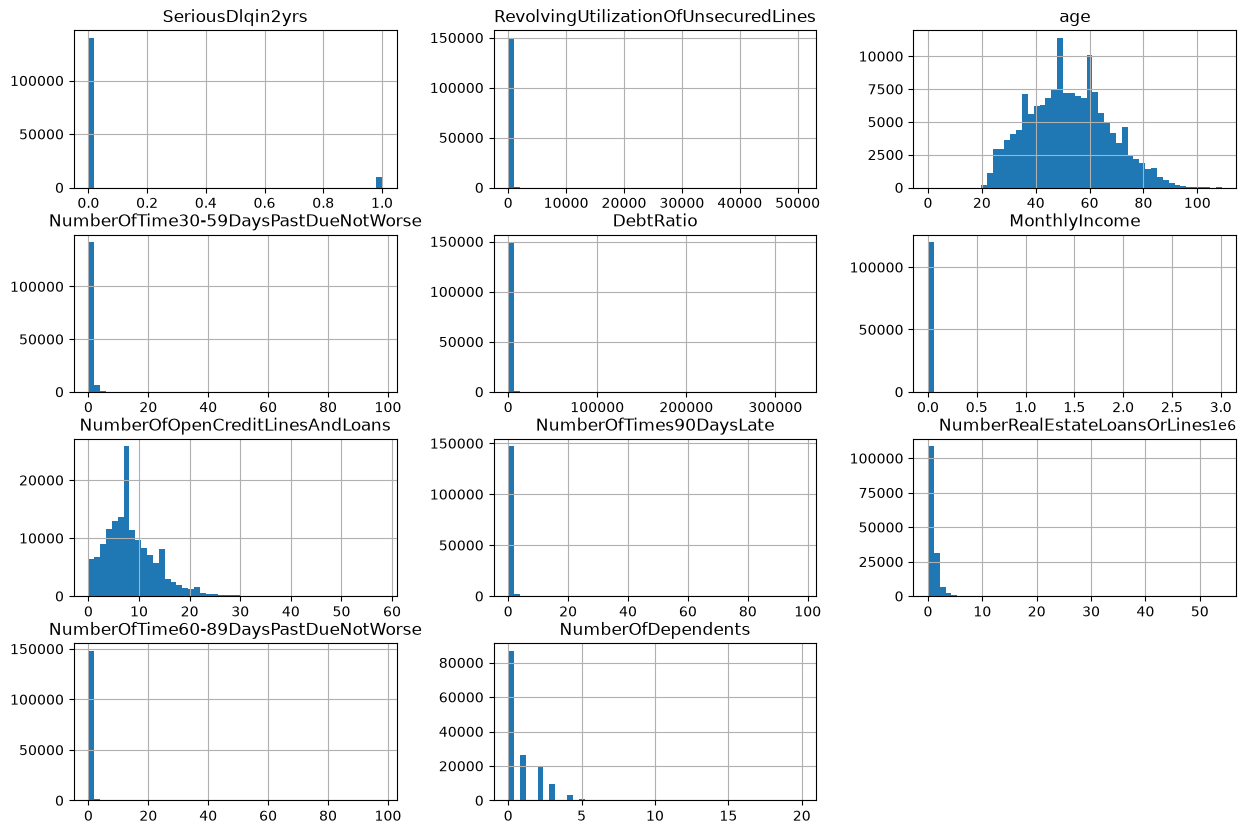

In [49]:
train.hist(figsize=(15,10), bins=50)

SeriousDlqin2yrs                           Axes(0.125,0.712609;0.227941x0.167391)
RevolvingUtilizationOfUnsecuredLines    Axes(0.398529,0.712609;0.227941x0.167391)
age                                     Axes(0.672059,0.712609;0.227941x0.167391)
NumberOfTime30-59DaysPastDueNotWorse       Axes(0.125,0.511739;0.227941x0.167391)
DebtRatio                               Axes(0.398529,0.511739;0.227941x0.167391)
MonthlyIncome                           Axes(0.672059,0.511739;0.227941x0.167391)
NumberOfOpenCreditLinesAndLoans             Axes(0.125,0.31087;0.227941x0.167391)
NumberOfTimes90DaysLate                  Axes(0.398529,0.31087;0.227941x0.167391)
NumberRealEstateLoansOrLines             Axes(0.672059,0.31087;0.227941x0.167391)
NumberOfTime60-89DaysPastDueNotWorse           Axes(0.125,0.11;0.227941x0.167391)
NumberOfDependents                          Axes(0.398529,0.11;0.227941x0.167391)
dtype: object

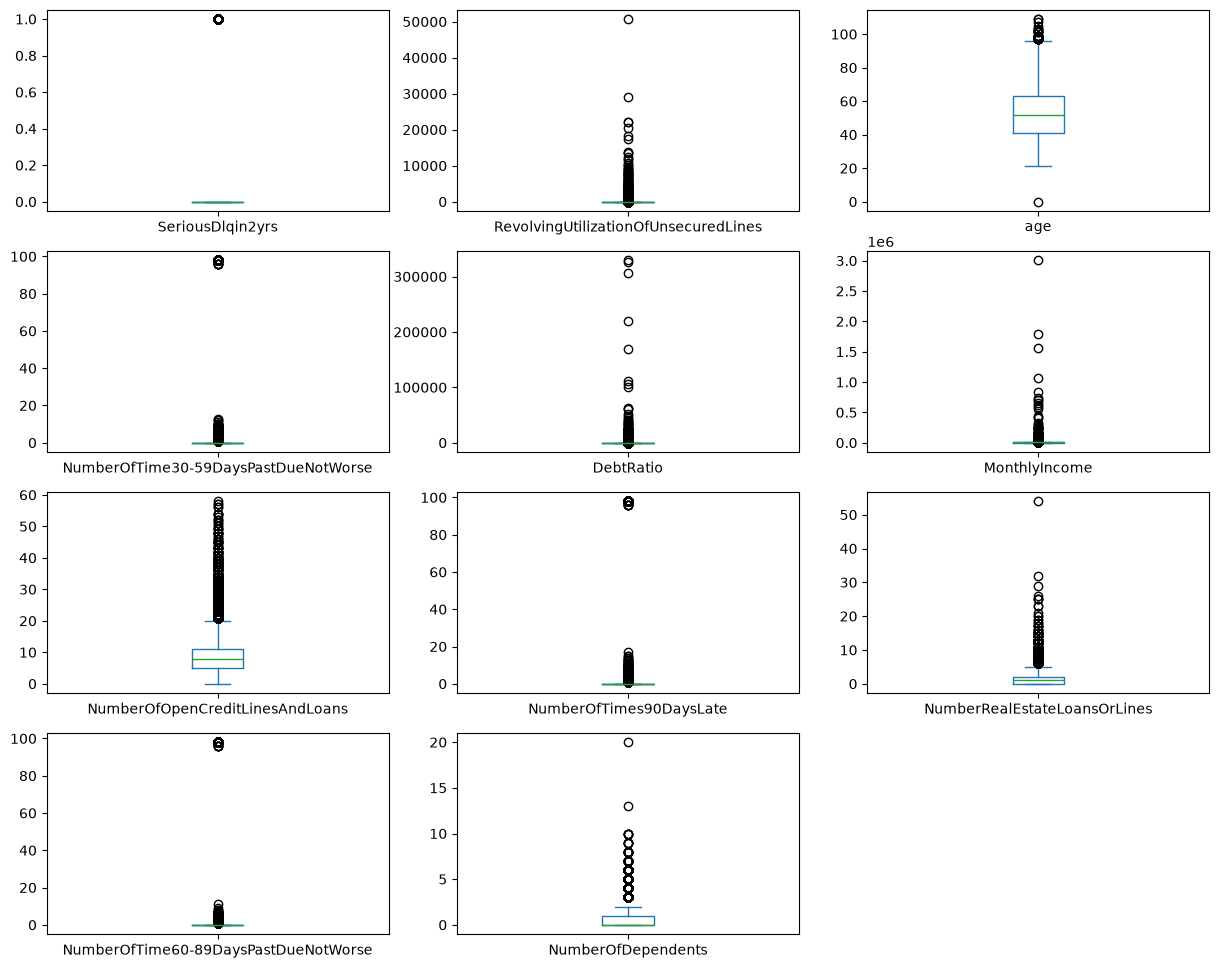

In [62]:
train.plot(kind='box', subplots=True, layout=(4, 3), figsize=(15, 12), sharex=False, sharey=False)


In [50]:
train.groupby('SeriousDlqin2yrs').mean()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
SeriousDlqin2yrs,,,,,,,,,,
0,6.168855,52.751375,0.280109,357.151168,6747.837774,8.493620,0.135225,1.020368,0.126666,0.743417
1,4.367282,45.926591,2.388490,295.121066,5630.826493,7.882306,2.091362,0.988530,1.828047,0.948208


In [52]:
train.corr()['SeriousDlqin2yrs'].sort_values()

age                                    -0.115386
NumberOfOpenCreditLinesAndLoans        -0.029669
MonthlyIncome                          -0.019746
DebtRatio                              -0.007602
NumberRealEstateLoansOrLines           -0.007038
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberOfDependents                      0.046048
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfTimes90DaysLate                 0.117175
NumberOfTime30-59DaysPastDueNotWorse    0.125587
SeriousDlqin2yrs                        1.000000
Name: SeriousDlqin2yrs, dtype: float64

<Axes: >

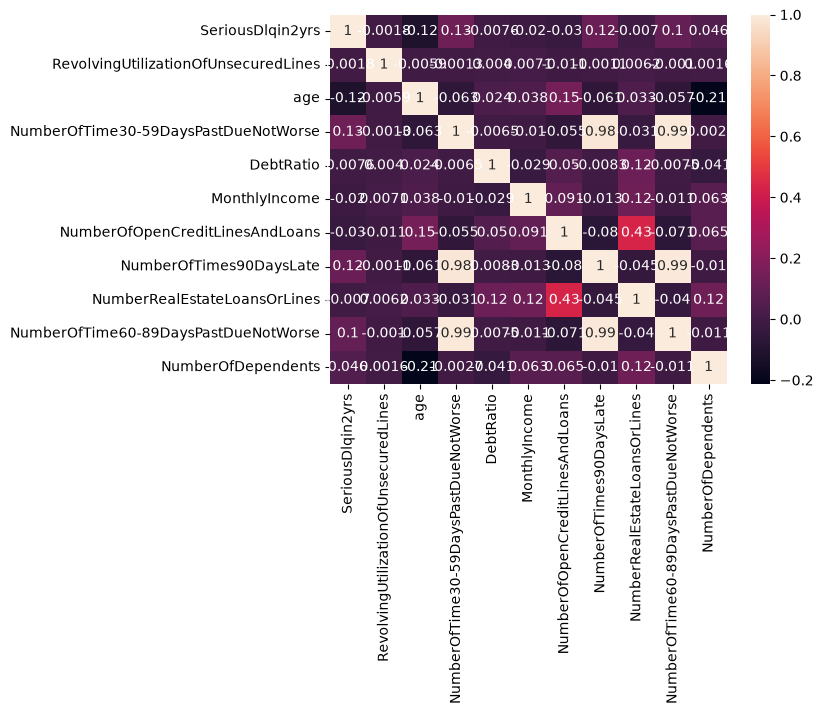

In [57]:
sns.heatmap(train.corr(), annot=True)

In [63]:
train['NumberOfTimes90DaysLate'].value_counts().sort_index(ascending=False).head(10)

NumberOfTimes90DaysLate
98    264
96      5
17      1
15      2
14      2
13      4
12      2
11      5
10      8
9      19
Name: count, dtype: int64

In [67]:
train[train['NumberOfTimes90DaysLate'].isin([96, 98])].describe().T


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,269.0,0.546468,4.987639e-01,0.0,0.0,1.0,1.0,1.0
RevolvingUtilizationOfUnsecuredLines,269.0,1.000000,1.112292e-16,1.0,1.0,1.0,1.0,1.0
age,269.0,34.245353,1.306182e+01,21.0,24.0,29.0,43.0,79.0
NumberOfTime30-59DaysPastDueNotWorse,269.0,97.962825,2.706284e-01,96.0,98.0,98.0,98.0,98.0
DebtRatio,269.0,5.739667,2.601902e+01,0.0,0.0,0.0,0.0,255.0
MonthlyIncome,148.0,2557.135135,2.745778e+03,0.0,1333.0,2168.5,3174.5,28733.0
NumberOfOpenCreditLinesAndLoans,269.0,0.007435,8.606510e-02,0.0,0.0,0.0,0.0,1.0
NumberOfTimes90DaysLate,269.0,97.962825,2.706284e-01,96.0,98.0,98.0,98.0,98.0
NumberRealEstateLoansOrLines,269.0,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0
NumberOfTime60-89DaysPastDueNotWorse,269.0,97.962825,2.706284e-01,96.0,98.0,98.0,98.0,98.0


In [68]:
train[train['age'] == 0]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [72]:
train[train['MonthlyIncome'].isna()]['DebtRatio'].describe()

count     29731.000000
mean       1673.396556
std        4248.372895
min           0.000000
25%         123.000000
50%        1159.000000
75%        2382.000000
max      329664.000000
Name: DebtRatio, dtype: float64

In [74]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [75]:
test.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RevolvingUtilizationOfUnsecuredLines,101503.0,5.310000,196.156039,0.0,0.030131,0.152586,0.564225,21821.0
age,101503.0,52.405436,14.779756,21.0,41.000000,52.000000,63.000000,104.0
NumberOfTime30-59DaysPastDueNotWorse,101503.0,0.453770,4.538487,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,101503.0,344.475020,1632.595231,0.0,0.173423,0.364260,0.851619,268326.0
MonthlyIncome,81400.0,6855.035590,36508.600375,0.0,3408.000000,5400.000000,8200.000000,7727000.0
NumberOfOpenCreditLinesAndLoans,101503.0,8.453514,5.144100,0.0,5.000000,8.000000,11.000000,85.0
NumberOfTimes90DaysLate,101503.0,0.296691,4.515859,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,101503.0,1.013074,1.110253,0.0,0.000000,1.000000,2.000000,37.0
NumberOfTime60-89DaysPastDueNotWorse,101503.0,0.270317,4.503578,0.0,0.000000,0.000000,0.000000,98.0


In [76]:
# drop age == 0
train = train[train['age'] > 0]

In [79]:
mask = train['NumberOfTimes90DaysLate'].isin([96,98])
mask.mean() * 100

np.float64(0.17933452889685933)

In [80]:
#drop nonsense 96, 98 rows
train = train[~mask]

In [112]:
train['DebtRatio'].quantile([0.5, 0.75, 0.9, 0.95, 0.975, 0.999])

0.500    0.368906
0.750    0.878141
0.900    2.500000
0.950    2.500000
0.975    2.500000
0.999    2.500000
Name: DebtRatio, dtype: float64

In [111]:
# drop extrimal DebtRatio
train['DebtRatio'] = train['DebtRatio'].clip(upper=2.5)
train['RevolvingUtilizationOfUnsecuredLines'] = train['RevolvingUtilizationOfUnsecuredLines'].clip(upper=10)

In [86]:
# filling nans in MonthlyIncome and NumberOfDependents

train['MonthlyIncomeMissing'] = train['MonthlyIncome'].isna().astype(int)
train['MonthlyIncome'] = train['MonthlyIncome'].fillna(train['MonthlyIncome'].median())

train['NumberOfDependents'] = train['NumberOfDependents'].fillna(0)

In [88]:
# drop duplicates
train = train.drop_duplicates(keep='first')

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncomeMissing
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
149996,False,False,False,False,False,False,False,False,False,False,False,False
149997,False,False,False,False,False,False,False,False,False,False,False,False
149998,False,False,False,False,False,False,False,False,False,False,False,False
149999,False,False,False,False,False,False,False,False,False,False,False,False


In [106]:
train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncomeMissing
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0
